# 414 — Depth-Varying Manning's n for HEC-RAS 2D Models

Manning's roughness coefficient varies with flow depth — this is well-established
in hydraulic literature (Chow 1959, HEC-15, Limerinos 1970, Jarrett 1984) but
often ignored in practice because HEC-RAS 2D models default to uniform roughness.

This notebook demonstrates a complete workflow for implementing **depth-varying
Manning's n** in HEC-RAS 2D face property tables using `ras-commander`:

1. **Literature grounding** — formulas that relate n to hydraulic radius
2. **Edit-run-read loop** — modify geometry, execute, verify face tables
3. **Face property table extension** — extend tables to higher elevations with
   depth-varying n using the HEC-15 vegetal retardance concept
4. **Polygon mask API** — apply modifications selectively to channel faces using
   calibration regions or computed channel polygons
5. **Channel polygon strategies** — multiple approaches to identify channel cells

**Key insight**: HEC-RAS 2D face property tables store Manning's n as a function
of elevation for each cell face. By **extending** these tables to higher elevations
with a depth-varying formula, we can model the physical reality that roughness
decreases with increasing flow depth.

**API methods demonstrated**:

| Method | Purpose |
|--------|---------|
| `GeomStorage.get/set_2d_flow_area_settings()` | Uniform Manning's n in `.g##` |
| `HdfMesh.get_mesh_face_property_tables()` | Read face-level n from geometry HDF |
| `HdfMesh.set_face_mannings_n_values()` | Replace n column with custom function |
| `HdfMesh.extend_face_property_tables()` | Extend tables to higher elevations |
| `HdfMesh.get_face_ids_in_polygon()` | Spatial filter: faces within a polygon |
| `HdfMesh.get_face_ids_in_calibration_region()` | Filter by named calibration region |
| `HdfMesh.pin_property_tables()` | Set Pinned attribute on mesh group |
| `HdfFluvialPluvial.generate_fluvial_pluvial_polygons()` | Channel delineation |
| `HdfXsec.get_river_bank_lines()` | Bank line extraction for channel polygon |

## Workflow Overview

```mermaid
flowchart LR
    A[Read Geometry<br/>Settings] --> B[Identify Channel<br/>Region]
    B --> C[Read Face<br/>Property Tables]
    C --> D[Extend Tables<br/>Depth-Varying n]
    D --> E[Pin Tables]
    E --> F[Run Model]
    F --> G[Compare Results<br/>Baseline vs Modified]

    style A fill:#e1f5fe
    style D fill:#fff3e0
    style G fill:#e8f5e9
```

The critical step is **D: Extend Tables** — we append rows above the current
maximum elevation using a depth-varying Manning's n function. This gives
HEC-RAS the information it needs to use lower roughness values at higher
water depths, matching the physics described by HEC-15 and other formulas.

## Literature: Why Manning's n Varies with Depth

Manning's n is **not a constant** — it varies with the ratio of flow depth to
roughness element size (relative roughness R/k_s). At shallow depths, roughness
elements dominate the water column and form drag is high. At greater depths,
skin friction dominates and effective roughness decreases.

> *"If the depth of flow is shallow in relation to the size of the roughness
> elements, the n value can be large, and the n value decreases with
> increasing depth."* — Chow, V.T., 1959. *Open-Channel Hydraulics*

### Key Formulas

**HEC-15 Vegetal Retardance** (FHWA, [HEC-15 3rd Ed. 2005](https://www.fhwa.dot.gov/engineering/hydraulics/pubs/05114/05114.pdf)):

$$n = \frac{R^{1/6}}{X + 19.97 \cdot \log(R^{1.4} \cdot S^{0.4})}$$

where X is a retardance class coefficient (A=15.8 through E=37.7).

**Limerinos (1970)** ([USGS WSP 1898-B](https://pubs.usgs.gov/wsp/1898b/report.pdf)) — gravel-bed rivers:

$$n = \frac{0.0926 \cdot R^{1/6}}{1.16 + 2.0 \cdot \log_{10}(R/d_{84})}$$

**Jarrett (1984)** — high-gradient streams (S > 0.002):

$$n = 0.39 \cdot S^{0.38} \cdot R^{-0.16}$$

All three formulas show that **n decreases as hydraulic radius R (a proxy for
depth) increases** relative to roughness element size.

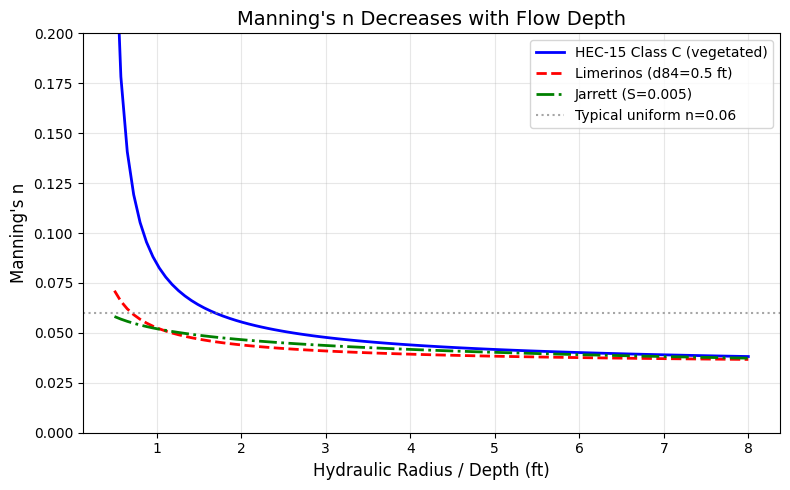

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Plot Manning's n vs depth for three formulas ---
depths = np.linspace(0.5, 8.0, 100)  # ft
S = 0.005   # slope
d84 = 0.5   # ft (gravel bed)

# HEC-15 Class C (moderate retardance)
X_C = 30.2
n_hec15 = depths**(1/6) / (X_C + 19.97 * np.log10(depths**1.4 * S**0.4))
n_hec15 = np.clip(n_hec15, 0.01, 0.3)

# Limerinos (1970)
n_lim = (0.0926 * depths**(1/6)) / (1.16 + 2.0 * np.log10(depths / d84))
n_lim = np.clip(n_lim, 0.01, 0.3)

# Jarrett (1984)
n_jar = 0.39 * S**0.38 * depths**(-0.16)
n_jar = np.clip(n_jar, 0.01, 0.3)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, n_hec15, 'b-', linewidth=2, label='HEC-15 Class C (vegetated)')
ax.plot(depths, n_lim, 'r--', linewidth=2, label=f'Limerinos (d84={d84} ft)')
ax.plot(depths, n_jar, 'g-.', linewidth=2, label=f'Jarrett (S={S})')
ax.axhline(y=0.06, color='gray', linestyle=':', alpha=0.7, label='Typical uniform n=0.06')
ax.set_xlabel('Hydraulic Radius / Depth (ft)', fontsize=12)
ax.set_ylabel("Manning's n", fontsize=12)
ax.set_title("Manning's n Decreases with Flow Depth", fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(0, 0.20)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from ras_commander import (
        init_ras_project, RasCmdr, RasExamples, ras,
        get_logger
    )
    from ras_commander.geom import GeomLandCover, GeomStorage
    from ras_commander.hdf import (
        HdfMesh, HdfResultsMesh, HdfResultsPlan,
        HdfFluvialPluvial, HdfXsec,
    )
except ImportError:
    current_file = Path(".").resolve()
    sys.path.append(str(current_file.parent))
    from ras_commander import (
        init_ras_project, RasCmdr, RasExamples, ras,
        get_logger
    )
    from ras_commander.geom import GeomLandCover, GeomStorage
    from ras_commander.hdf import (
        HdfMesh, HdfResultsMesh, HdfResultsPlan,
        HdfFluvialPluvial, HdfXsec,
    )

logger = get_logger(__name__)

## Configuration

In [3]:
PROJECT_NAME = "Muncie"
RAS_VERSION = "6.6"
PLAN_NUMBER = "03"          # Unsteady Run with 2D 50ft Grid (uses g02)
MESH_NAME = "2D Interior Area"
GEOM_NUMBER = "02"

# Manning's n modification factor for the uniform-n edit-run-read loop
N_MULTIPLIER = 2.0

# Depth-varying n parameters (exponential decay toward asymptote)
N_ASYMPTOTE = 0.045   # Deep-flow Manning's n
DEPTH_HALF = 1.0      # Depth at which n decays to ~37% of excess above asymptote

## Step 1: Extract Baseline and Modified Projects

We extract two independent copies of Muncie so the baseline stays pristine.

In [4]:
baseline_path = RasExamples.extract_project(PROJECT_NAME, suffix="414_baseline")
modified_path = RasExamples.extract_project(PROJECT_NAME, suffix="414_modified")

print(f"Baseline: {baseline_path}")
print(f"Modified: {modified_path}")

baseline_ras = init_ras_project(baseline_path, RAS_VERSION, ras_object="new")
plan_row = baseline_ras.plan_df[baseline_ras.plan_df['plan_number'] == PLAN_NUMBER].iloc[0]
print(f"\nPlan {PLAN_NUMBER}: {plan_row['Plan Title']}")
print(f"Geometry: g{str(plan_row['geometry_number']).zfill(2)}")

2026-05-12 08:22:42 - ras_commander.RasExamples - INFO - Found zip file: C:\Users\bill\AppData\Local\ras-commander\examples\Example_Projects_7_0.zip


2026-05-12 08:22:42 - ras_commander.RasExamples - INFO - Loading project data from CSV...


2026-05-12 08:22:42 - ras_commander.RasExamples - INFO - Loaded 67 projects from CSV.


2026-05-12 08:22:42 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-05-12 08:22:42 - ras_commander.RasExamples - INFO - Extracting project 'Muncie' as 'Muncie_414_baseline'


...

2026-05-12 08:22:43 - ras_commander.RasPrj - INFO - Updated results_df with 3 plan(s)


2026-05-12 08:22:43 - ras_commander.RasPrj - INFO - ras-commander v0.96.2 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-05-12 08:22:43 - ras_commander.RasPrj - INFO - Project initialized: Muncie | Folder: G:\GH\ras-commander\example_projects\Muncie_414_baseline


2026-05-12 08:22:43 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


Baseline: G:\GH\ras-commander\example_projects\Muncie_414_baseline
Modified: G:\GH\ras-commander\example_projects\Muncie_414_modified

Plan 03: Unsteady Run with 2D 50ft Grid
Geometry: g02


## Step 2: Read Current Manning's n Settings

Muncie uses a **uniform** Manning's n (0.06) for the entire 2D flow area.
The land cover table exists but is inactive because *Spatially Varied Manning's
on Faces* is disabled.

In [5]:
baseline_geom = baseline_path / f"{baseline_ras.project_name}.g{GEOM_NUMBER}"
modified_geom = modified_path / f"{baseline_ras.project_name}.g{GEOM_NUMBER}"

settings = GeomStorage.get_2d_flow_area_settings(baseline_geom)
area_row = settings[settings['name'] == MESH_NAME].iloc[0]
original_n = area_row['mannings_n']
spatially_varied = area_row.get('spatially_varied_mann_on_faces', False)

print(f"2D Flow Area: '{MESH_NAME}'")
print(f"  Uniform Manning's n: {original_n}")
print(f"  Spatially varied: {spatially_varied}")

original_mannings = GeomLandCover.get_base_mannings_n(baseline_geom)
print(f"\nLand cover table ({len(original_mannings)} classes):")
print(original_mannings.to_string(index=False))

2D Flow Area: '2D Interior Area'
  Uniform Manning's n: 0.06
  Spatially varied: False

Land cover table (7 classes):
Table Number            Land Cover Name  Base Mannings n Value
           7                     NoData                   0.06
           7                   Building                  10.00
           7 Medium Density Residential                   0.08
           7                 Open Space                   0.04
           7                       Park                   0.06
           7                      Trees                   0.12
           7                      Urban                   0.10


## Step 3: Modify Uniform Manning's n

We double the roughness (0.06 → 0.12) in the modified copy's plain-text
geometry file. The round-trip assertion verifies the write was successful.

In [6]:
new_n = original_n * N_MULTIPLIER

GeomStorage.set_2d_flow_area_settings(
    modified_geom, flow_area_name=MESH_NAME, mannings_n=new_n,
)

mod_settings = GeomStorage.get_2d_flow_area_settings(modified_geom)
verify_n = mod_settings[mod_settings['name'] == MESH_NAME].iloc[0]['mannings_n']

print(f"Uniform Manning's n: {original_n} -> {verify_n}  ({verify_n/original_n:.1f}x)")
assert abs(verify_n - new_n) < 1e-6, f"Round-trip failed: expected {new_n}, got {verify_n}"
print("Round-trip verified")

2026-05-12 08:22:43 - ras_commander.geom.GeomParser - INFO - Created backup: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.bak


2026-05-12 08:22:43 - ras_commander.geom.GeomStorage - INFO - Created backup: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.bak


2026-05-12 08:22:43 - ras_commander.geom.GeomStorage - INFO - Updated 2D flow area settings for 2D Interior Area


Uniform Manning's n: 0.06 -> 0.12  (2.0x)
Round-trip verified


## Step 4: Run Both Models

Both runs use `force_geompre=True` to regenerate the geometry HDF from the
modified plain-text file. HEC-RAS preprocessing converts the uniform n into
per-face property tables.

In [7]:
baseline_ras = init_ras_project(baseline_path, RAS_VERSION, ras_object="new")
print("Running baseline model...")
RasCmdr.compute_plan(PLAN_NUMBER, ras_object=baseline_ras, num_cores=2, force_geompre=True)
baseline_ras = init_ras_project(baseline_path, RAS_VERSION, ras_object="new")

messages = HdfResultsPlan.get_compute_messages(PLAN_NUMBER, ras_object=baseline_ras)
if messages:
    lines = messages.splitlines()
    errors = [l for l in lines if "ERROR" in l.upper()
              and "VOLUME ACCOUNTING" not in l.upper()
              and "WSEL ERROR" not in l.upper()
              and "ITERATIONS" not in l.upper()]
    print(f"Baseline: {len(lines)} messages, {len(errors)} errors")
else:
    print("Baseline complete")

2026-05-12 08:22:43 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-05-12 08:22:43 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-05-12 08:22:43 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-05-12 08:22:43 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.3.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.3.1\Ras.exe via filesystem (x86)


2026-05-12 08:22:43 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.2 at C:\Program Files (x86)\HEC\HEC-RAS\6.2\Ras.exe via filesystem (x86)


...

2026-05-12 08:23:16 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


2026-05-12 08:23:16 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.p03.hdf


2026-05-12 08:23:16 - ras_commander.hdf.HdfResultsPlan - INFO - Reading computation messages from HDF: Muncie.p03.hdf


2026-05-12 08:23:16 - ras_commander.hdf.HdfResultsPlan - INFO - Successfully extracted 2157 characters from HDF


Baseline: 74 messages, 0 errors


In [8]:
modified_ras = init_ras_project(modified_path, RAS_VERSION, ras_object="new")
print("Running modified model (2x Manning's n)...")
RasCmdr.compute_plan(PLAN_NUMBER, ras_object=modified_ras, num_cores=2, force_geompre=True)
modified_ras = init_ras_project(modified_path, RAS_VERSION, ras_object="new")

messages = HdfResultsPlan.get_compute_messages(PLAN_NUMBER, ras_object=modified_ras)
if messages:
    lines = messages.splitlines()
    errors = [l for l in lines if "ERROR" in l.upper()
              and "VOLUME ACCOUNTING" not in l.upper()
              and "WSEL ERROR" not in l.upper()
              and "ITERATIONS" not in l.upper()]
    print(f"Modified: {len(lines)} messages, {len(errors)} errors")
else:
    print("Modified complete")

2026-05-12 08:23:16 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-05-12 08:23:16 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-05-12 08:23:16 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-05-12 08:23:16 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.3.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.3.1\Ras.exe via filesystem (x86)


2026-05-12 08:23:16 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.2 at C:\Program Files (x86)\HEC\HEC-RAS\6.2\Ras.exe via filesystem (x86)


...

2026-05-12 08:23:50 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


2026-05-12 08:23:50 - ras_commander.hdf.HdfResultsPlan - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.p03.hdf


2026-05-12 08:23:50 - ras_commander.hdf.HdfResultsPlan - INFO - Reading computation messages from HDF: Muncie.p03.hdf


2026-05-12 08:23:50 - ras_commander.hdf.HdfResultsPlan - INFO - Successfully extracted 2157 characters from HDF


Modified: 74 messages, 0 errors


## Step 5: Face Property Table Comparison

The face property tables encode Manning's n as a function of elevation for
each cell face. After doubling the uniform n, every face should show 0.12
instead of 0.06. We visualize a representative face to confirm.

2026-05-12 08:23:50 - ras_commander.hdf.HdfMesh - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.g02.hdf


2026-05-12 08:23:50 - ras_commander.hdf.HdfMesh - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.g02.hdf


2026-05-12 08:23:50 - ras_commander.hdf.HdfMesh - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.g02.hdf


2026-05-12 08:23:50 - ras_commander.hdf.HdfMesh - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.g02.hdf


2026-05-12 08:23:50 - ras_commander.hdf.HdfMesh - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.hdf


2026-05-12 08:23:50 - ras_commander.hdf.HdfMesh - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.hdf


2026-05-12 08:23:50 - ras_commander.hdf.HdfMesh - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.hdf


2026-05-12 08:23:50 - ras_commander.hdf.HdfMesh - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.hdf


Baseline: 11164 faces, 47055 rows
Modified: 11164 faces, 47055 rows
Baseline mean n: 0.0600
Modified mean n: 0.1200
Ratio: 2.00x


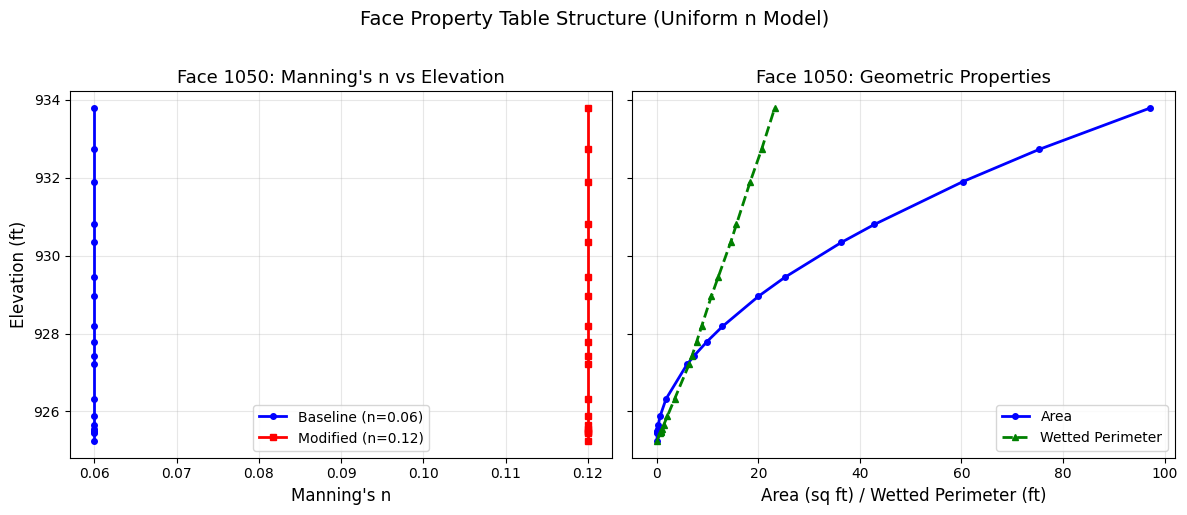

In [9]:
baseline_geom_hdf = baseline_path / f"{baseline_ras.project_name}.g{GEOM_NUMBER}.hdf"
modified_geom_hdf = modified_path / f"{modified_ras.project_name}.g{GEOM_NUMBER}.hdf"

base_tables = HdfMesh.get_mesh_face_property_tables(baseline_geom_hdf)
mod_tables = HdfMesh.get_mesh_face_property_tables(modified_geom_hdf)

base_df = base_tables[MESH_NAME]
mod_df = mod_tables[MESH_NAME]
n_col = "Manning's n"

print(f"Baseline: {base_df['Face ID'].nunique()} faces, {len(base_df)} rows")
print(f"Modified: {mod_df['Face ID'].nunique()} faces, {len(mod_df)} rows")
print(f"Baseline mean n: {base_df[n_col].mean():.4f}")
print(f"Modified mean n: {mod_df[n_col].mean():.4f}")
print(f"Ratio: {mod_df[n_col].mean() / base_df[n_col].mean():.2f}x")

# --- Figure: Face property table comparison for a sample face ---
sample_face = 1050
base_sample = base_df[base_df['Face ID'] == sample_face]
mod_sample = mod_df[mod_df['Face ID'] == sample_face]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: Manning's n vs Elevation
ax = axes[0]
ax.plot(base_sample[n_col], base_sample['Elevation'], 'b-o', markersize=4,
        label=f'Baseline (n={original_n})', linewidth=2)
ax.plot(mod_sample[n_col], mod_sample['Elevation'], 'r-s', markersize=4,
        label=f'Modified (n={new_n})', linewidth=2)
ax.set_xlabel("Manning's n", fontsize=12)
ax.set_ylabel('Elevation (ft)', fontsize=12)
ax.set_title(f'Face {sample_face}: Manning\'s n vs Elevation', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: Area vs Elevation (unchanged between runs)
ax = axes[1]
ax.plot(base_sample['Area'], base_sample['Elevation'], 'b-o', markersize=4,
        label='Area', linewidth=2)
ax.plot(base_sample['Wetted Perimeter'], base_sample['Elevation'], 'g--^',
        markersize=4, label='Wetted Perimeter', linewidth=2)
ax.set_xlabel('Area (sq ft) / Wetted Perimeter (ft)', fontsize=12)
ax.set_title(f'Face {sample_face}: Geometric Properties', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle('Face Property Table Structure (Uniform n Model)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## Step 6: Compare Simulation Results

Higher Manning's n increases flow resistance, producing different water surface
elevations. We quantify the impact across all mesh cells.

Wet cells compared: 5765
Mean delta WSE:     +0.1110 ft
Max delta WSE:      +0.8646 ft
Min delta WSE:      -0.0919 ft
Cells with |delta| > 0.001 ft: 4980/5765 (86.4%)


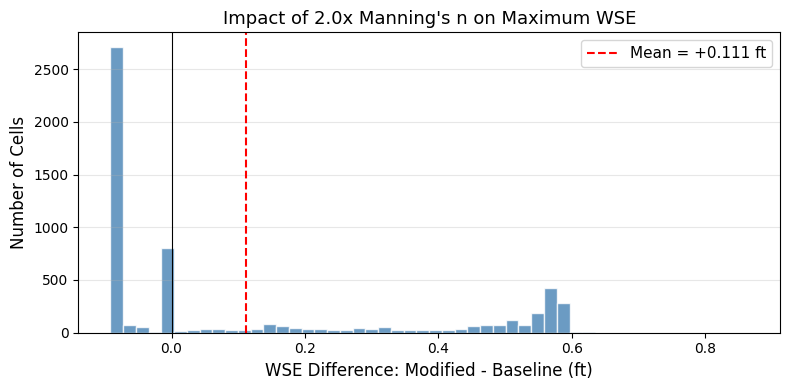


Edit-run-read loop verified: 2.0x roughness impacted 4980 cells


In [10]:
import h5py

base_hdf_path = Path(baseline_ras.plan_df.loc[
    baseline_ras.plan_df['plan_number'] == PLAN_NUMBER, 'HDF_Results_Path'
].iloc[0])
mod_hdf_path = Path(modified_ras.plan_df.loc[
    modified_ras.plan_df['plan_number'] == PLAN_NUMBER, 'HDF_Results_Path'
].iloc[0])

summary_path = (
    f"Results/Unsteady/Output/Output Blocks/Base Output/"
    f"Summary Output/2D Flow Areas/{MESH_NAME}/Maximum Water Surface"
)

with h5py.File(str(base_hdf_path), 'r') as fb, \
     h5py.File(str(mod_hdf_path), 'r') as fm:
    base_wse = fb[summary_path][:][0, :]
    mod_wse = fm[summary_path][:][0, :]

delta = mod_wse - base_wse
valid = np.isfinite(delta) & (base_wse > -100) & (mod_wse > -100)
delta_valid = delta[valid]

print(f"Wet cells compared: {valid.sum()}")
print(f"Mean delta WSE:     {np.mean(delta_valid):+.4f} ft")
print(f"Max delta WSE:      {np.max(delta_valid):+.4f} ft")
print(f"Min delta WSE:      {np.min(delta_valid):+.4f} ft")

n_changed = np.sum(np.abs(delta_valid) > 0.001)
print(f"Cells with |delta| > 0.001 ft: {n_changed}/{valid.sum()} ({100*n_changed/max(valid.sum(),1):.1f}%)")

# --- Figure: WSE difference histogram ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(delta_valid, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.axvline(x=np.mean(delta_valid), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {np.mean(delta_valid):+.3f} ft')
ax.set_xlabel('WSE Difference: Modified - Baseline (ft)', fontsize=12)
ax.set_ylabel('Number of Cells', fontsize=12)
ax.set_title(f'Impact of {N_MULTIPLIER}x Manning\'s n on Maximum WSE', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

assert n_changed > 0, "Expected WSE changes from Manning's n modification"
print(f"\nEdit-run-read loop verified: {N_MULTIPLIER}x roughness impacted {n_changed} cells")

## Step 7: Apply Depth-Varying Manning's n

Instead of a uniform roughness, we apply a physically-based formula where n
**decreases with flow depth** — consistent with HEC-15 and Limerinos. We use
an exponential decay model:

$$n(d) = n_{\text{asymptote}} + (n_{\text{base}} - n_{\text{asymptote}}) \cdot e^{-d/d_{1/2}}$$

This captures the key physics: at shallow depths, n equals the base value
(set during preprocessing). As depth increases, n decays toward the asymptote.

We apply this to the **already-preprocessed** geometry HDF using
`HdfMesh.set_face_mannings_n_values()`, which replaces the n column in each
face's property table while preserving elevation, area, and wetted perimeter.

2026-05-12 08:23:52 - ras_commander.hdf.HdfMesh - INFO - Wrote face property tables for 11164 faces in mesh '2D Interior Area' (47055 total rows)


2026-05-12 08:23:52 - ras_commander.hdf.HdfMesh - INFO - Modified Manning's n for 11164 faces in mesh '2D Interior Area'


2026-05-12 08:23:52 - ras_commander.hdf.HdfMesh - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.hdf


2026-05-12 08:23:52 - ras_commander.hdf.HdfMesh - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.hdf


2026-05-12 08:23:52 - ras_commander.hdf.HdfMesh - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.hdf


2026-05-12 08:23:52 - ras_commander.hdf.HdfMesh - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.hdf


Applied depth-varying n to 11164 faces


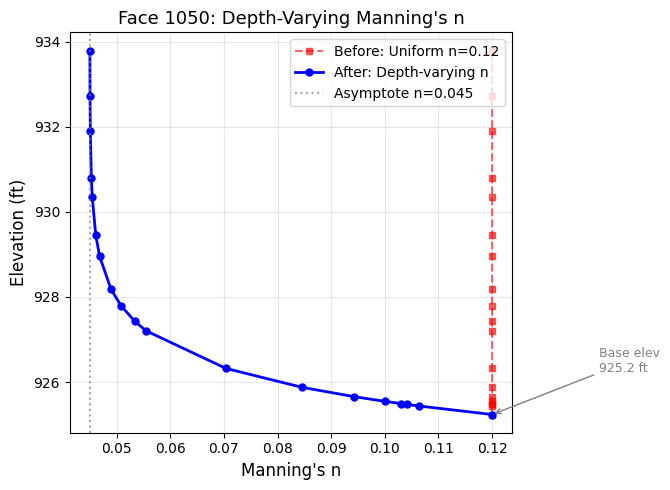


n at base (d=0):   0.1200
n at top  (d=8.6 ft): 0.0450


In [11]:
def vegetal_retardance(elevation, depth, current_n):
    """Exponential decay: n decreases from current_n toward N_ASYMPTOTE with depth."""
    if depth <= 0:
        return current_n
    return N_ASYMPTOTE + (current_n - N_ASYMPTOTE) * np.exp(-depth / DEPTH_HALF)

num_modified = HdfMesh.set_face_mannings_n_values(
    hdf_path=modified_geom_hdf,
    mesh_name=MESH_NAME,
    mannings_n_func=vegetal_retardance,
    face_ids=None,
    pin_tables=False,
)
print(f"Applied depth-varying n to {num_modified} faces")

# Read back and visualize
after_tables = HdfMesh.get_mesh_face_property_tables(modified_geom_hdf)
after_df = after_tables[MESH_NAME]
after_sample = after_df[after_df['Face ID'] == sample_face]

# --- Figure: Before vs After depth-varying n ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mod_sample[n_col], mod_sample['Elevation'], 'r--s', markersize=4,
        label=f'Before: Uniform n={new_n}', linewidth=1.5, alpha=0.6)
ax.plot(after_sample[n_col], after_sample['Elevation'], 'b-o', markersize=5,
        label='After: Depth-varying n', linewidth=2)
ax.axvline(x=N_ASYMPTOTE, color='gray', linestyle=':', alpha=0.7,
           label=f'Asymptote n={N_ASYMPTOTE}')

base_elev = after_sample['Elevation'].iloc[0]
ax.annotate(f'Base elev\n{base_elev:.1f} ft',
            xy=(after_sample[n_col].iloc[0], base_elev),
            xytext=(after_sample[n_col].iloc[0] + 0.02, base_elev + 1),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

ax.set_xlabel("Manning's n", fontsize=12)
ax.set_ylabel('Elevation (ft)', fontsize=12)
ax.set_title(f'Face {sample_face}: Depth-Varying Manning\'s n', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"\nn at base (d=0):   {after_sample[n_col].iloc[0]:.4f}")
print(f"n at top  (d={after_sample['Elevation'].iloc[-1] - base_elev:.1f} ft): {after_sample[n_col].iloc[-1]:.4f}")

## Step 8: Extend Tables to Higher Elevations

The preprocessed face tables only reach the terrain elevation at each face.
For deep flood events, water may rise above this — and HEC-RAS extrapolates
with the last n value (constant, not depth-varying).

`HdfMesh.extend_face_property_tables()` appends rows from the current maximum
up to a target elevation, using a rectangular cross-section assumption for
area and wetted perimeter. The Manning's n function receives `(depth, base_n)`
so it can implement any depth-varying formula.

2026-05-12 08:23:55 - ras_commander.hdf.HdfMesh - INFO - Pinned property tables for mesh '2D Interior Area'


2026-05-12 08:23:55 - ras_commander.hdf.HdfMesh - INFO - Wrote face property tables for 11164 faces in mesh '2D Interior Area' (476525 total rows)


2026-05-12 08:23:55 - ras_commander.hdf.HdfMesh - INFO - Extended 11164 face tables in mesh '2D Interior Area', total rows added: 429470


2026-05-12 08:23:55 - ras_commander.hdf.HdfMesh - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.hdf


2026-05-12 08:23:55 - ras_commander.hdf.HdfMesh - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.hdf


2026-05-12 08:23:55 - ras_commander.hdf.HdfMesh - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.hdf


2026-05-12 08:23:55 - ras_commander.hdf.HdfMesh - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_modified\Muncie.g02.hdf


Extended 11164 faces, total rows added: 429470


Face 1050: 19 rows -> 71 rows
Elevation range: 925.24 - 959.79 ft


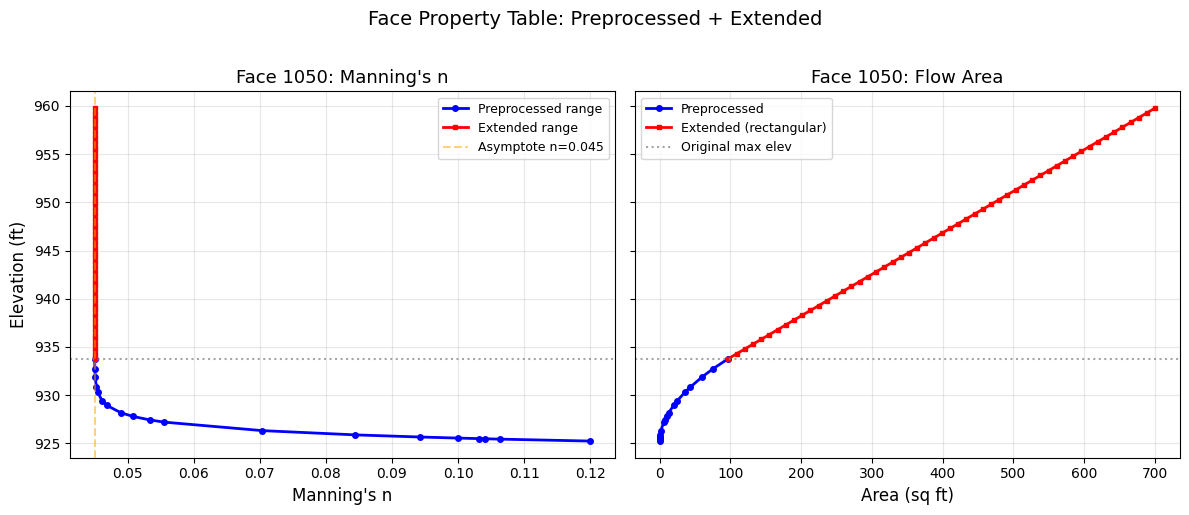

In [12]:
max_elev = base_df['Elevation'].max()
target_elev = max_elev + 5.0

def extend_n_func(depth, base_n):
    """Manning's n for extension rows (same exponential decay)."""
    if depth <= 0:
        return base_n
    return N_ASYMPTOTE + (base_n - N_ASYMPTOTE) * np.exp(-depth / DEPTH_HALF)

rows_added = HdfMesh.extend_face_property_tables(
    hdf_path=modified_geom_hdf,
    mesh_name=MESH_NAME,
    extension_elevation=target_elev,
    mannings_n_func=extend_n_func,
    elevation_step=0.5,
    face_ids=None,
    pin_tables=True,
)

print(f"Extended {len(rows_added)} faces, total rows added: {sum(rows_added.values())}")

# Read extended table
ext_tables = HdfMesh.get_mesh_face_property_tables(modified_geom_hdf)
ext_df = ext_tables[MESH_NAME]
ext_sample = ext_df[ext_df['Face ID'] == sample_face]

print(f"Face {sample_face}: {len(mod_sample)} rows -> {len(ext_sample)} rows")
print(f"Elevation range: {ext_sample['Elevation'].min():.2f} - {ext_sample['Elevation'].max():.2f} ft")

# --- Figure: Extended face property table ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax = axes[0]
# Original preprocessed range
orig_max_elev = mod_sample['Elevation'].max()
orig_portion = ext_sample[ext_sample['Elevation'] <= orig_max_elev + 0.01]
ext_portion = ext_sample[ext_sample['Elevation'] > orig_max_elev - 0.01]

ax.plot(orig_portion[n_col], orig_portion['Elevation'], 'b-o', markersize=4,
        label='Preprocessed range', linewidth=2)
ax.plot(ext_portion[n_col], ext_portion['Elevation'], 'r-s', markersize=3,
        label='Extended range', linewidth=2)
ax.axhline(y=orig_max_elev, color='gray', linestyle=':', alpha=0.7)
ax.axvline(x=N_ASYMPTOTE, color='orange', linestyle='--', alpha=0.5,
           label=f'Asymptote n={N_ASYMPTOTE}')
ax.set_xlabel("Manning's n", fontsize=12)
ax.set_ylabel('Elevation (ft)', fontsize=12)
ax.set_title(f"Face {sample_face}: Manning's n", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(orig_portion['Area'], orig_portion['Elevation'], 'b-o', markersize=4,
        label='Preprocessed', linewidth=2)
ax.plot(ext_portion['Area'], ext_portion['Elevation'], 'r-s', markersize=3,
        label='Extended (rectangular)', linewidth=2)
ax.axhline(y=orig_max_elev, color='gray', linestyle=':', alpha=0.7,
           label=f'Original max elev')
ax.set_xlabel('Area (sq ft)', fontsize=12)
ax.set_title(f'Face {sample_face}: Flow Area', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle('Face Property Table: Preprocessed + Extended', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## Step 9: Polygon Mask API — Selective Face Application

In practice, you want to apply depth-varying n **only to channel faces**, not
the entire mesh. `HdfMesh.extend_face_property_tables()` and
`set_face_mannings_n_values()` accept optional `polygon` or `region_name`
parameters for spatial filtering.

**Precedence**: `face_ids` > `region_name` > `polygon` > None (all faces)

### Channel Polygon Strategies

There are several ways to identify which faces are "in the channel":

1. **Calibration Regions** (recommended) — draw a region in RASMapper GUI,
   reference by name via `get_face_ids_in_calibration_region()`
2. **Fluvial/Pluvial Classification** — use `HdfFluvialPluvial` to identify
   fluvial cells from simulation results, then extract the fluvial polygon
3. **Bank Lines** — use `HdfXsec.get_river_bank_lines()` from the geometry
   HDF to construct a channel polygon between left and right banks

We demonstrate strategies 2 and 3 below using the Muncie model.

In [13]:
# --- Strategy A: Fluvial/Pluvial Classification ---
# Run the baseline model first (already done above), then classify cells
base_plan_hdf = base_hdf_path

print("Generating fluvial/pluvial classification...")
fp_gdf = HdfFluvialPluvial.generate_fluvial_pluvial_polygons(base_plan_hdf)

print(f"\nClassification results:")
for _, row in fp_gdf.iterrows():
    area_acres = row.geometry.area / 43560
    print(f"  {row['classification']}: {area_acres:.1f} acres")

# Extract the fluvial polygon (river corridor)
fluvial_mask = fp_gdf[fp_gdf['classification'] == 'fluvial']
if not fluvial_mask.empty:
    fluvial_polygon = fluvial_mask.geometry.iloc[0]
    fluvial_acres = fluvial_polygon.area / 43560
    print(f"\nFluvial polygon: {fluvial_acres:.0f} acres")
else:
    fluvial_polygon = None
    print("\nNo fluvial polygon generated")

2026-05-12 08:23:56 - ras_commander.hdf.HdfFluvialPluvial - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.p03.hdf


2026-05-12 08:23:56 - ras_commander.hdf.HdfFluvialPluvial - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.p03.hdf


2026-05-12 08:23:56 - ras_commander.hdf.HdfFluvialPluvial - INFO - Loading mesh and results data...


2026-05-12 08:23:56 - ras_commander.hdf.HdfMesh - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.p03.hdf


2026-05-12 08:23:56 - ras_commander.hdf.HdfMesh - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.p03.hdf


...

2026-05-12 08:23:57 - ras_commander.hdf.HdfFluvialPluvial - INFO - Region growing completed in 61 iterations.


2026-05-12 08:23:57 - ras_commander.hdf.HdfFluvialPluvial - INFO - Merging classifications with cell polygons...


2026-05-12 08:23:57 - ras_commander.hdf.HdfFluvialPluvial - INFO - Dissolving polygons by classification...


2026-05-12 08:23:57 - ras_commander.hdf.HdfFluvialPluvial - INFO - Polygon generation completed successfully.



Classification results:
  fluvial: 285.9 acres
  pluvial: 28.9 acres

Fluvial polygon: 286 acres


In [14]:
# --- Strategy B: Bank Lines from 1D Geometry ---
baseline_geom_hdf_02 = baseline_path / f"{baseline_ras.project_name}.g{GEOM_NUMBER}.hdf"

try:
    bank_lines = HdfXsec.get_river_bank_lines(baseline_geom_hdf_02)
    print(f"Bank lines found: {len(bank_lines)} lines")
    for _, row in bank_lines.iterrows():
        length_ft = row.geometry.length
        print(f"  {row.get('Name', 'bank')}: {length_ft:,.0f} ft ({length_ft/5280:.2f} mi)")
except Exception as e:
    bank_lines = None
    print(f"No bank lines in g{GEOM_NUMBER}: {e}")

# --- Get face IDs within the fluvial polygon ---
if fluvial_polygon is not None:
    channel_face_ids = HdfMesh.get_face_ids_in_polygon(
        baseline_geom_hdf, MESH_NAME, fluvial_polygon, method='midpoint'
    )
    total_faces = base_df['Face ID'].nunique()
    print(f"\nChannel faces (fluvial polygon): {len(channel_face_ids)} / {total_faces} "
          f"({100*len(channel_face_ids)/total_faces:.1f}%)")
else:
    channel_face_ids = None

2026-05-12 08:23:57 - ras_commander.hdf.HdfXsec - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.g02.hdf


2026-05-12 08:23:57 - ras_commander.hdf.HdfXsec - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.g02.hdf


2026-05-12 08:23:57 - ras_commander.hdf.HdfBase - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.g02.hdf


2026-05-12 08:23:57 - ras_commander.hdf.HdfBase - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.g02.hdf


2026-05-12 08:23:57 - ras_commander.hdf.HdfBase - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.g02.hdf


...

2026-05-12 08:23:58 - ras_commander.hdf.HdfBase - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.g02.hdf


2026-05-12 08:23:58 - ras_commander.hdf.HdfBase - INFO - Found projection in HDF file: G:\GH\ras-commander\example_projects\Muncie_414_baseline\Muncie.g02.hdf


Bank lines found: 2 lines
  bank: 15,513 ft (2.94 mi)
  bank: 15,835 ft (3.00 mi)


2026-05-12 08:23:58 - ras_commander.hdf.HdfMesh - INFO - Found 9832 faces in polygon (mesh '2D Interior Area', method='midpoint')



Channel faces (fluvial polygon): 9832 / 11164 (88.1%)


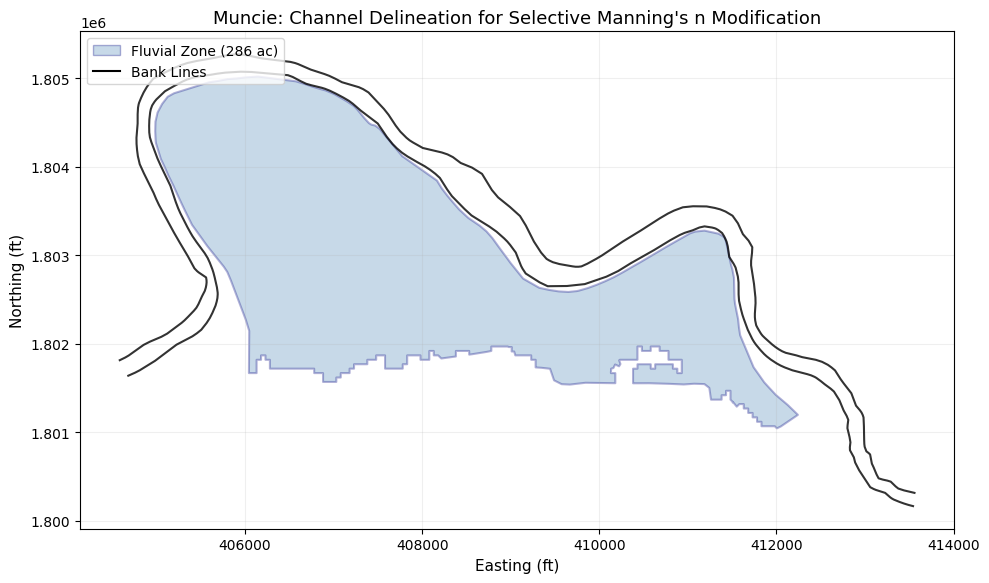

In [15]:
# --- Figure: Channel polygon and face locations ---
if fluvial_polygon is not None:
    from shapely.geometry import mapping
    import matplotlib.patches as mpatches
    from matplotlib.collections import PatchCollection
    from matplotlib.patches import Polygon as MplPolygon

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot fluvial polygon
    if fluvial_polygon.geom_type == 'Polygon':
        coords = np.array(fluvial_polygon.exterior.coords)
        patch = MplPolygon(coords[:, :2], closed=True)
        p = PatchCollection([patch], alpha=0.3, facecolor='steelblue', edgecolor='navy', linewidth=1.5)
        ax.add_collection(p)
    elif fluvial_polygon.geom_type == 'MultiPolygon':
        patches = []
        for geom in fluvial_polygon.geoms:
            coords = np.array(geom.exterior.coords)
            patches.append(MplPolygon(coords[:, :2], closed=True))
        p = PatchCollection(patches, alpha=0.3, facecolor='steelblue', edgecolor='navy', linewidth=1.5)
        ax.add_collection(p)

    # Plot bank lines if available
    if bank_lines is not None and not bank_lines.empty:
        for _, row in bank_lines.iterrows():
            coords = np.array(row.geometry.coords)
            ax.plot(coords[:, 0], coords[:, 1], 'k-', linewidth=1.5, alpha=0.8)
        ax.plot([], [], 'k-', linewidth=1.5, label='Bank Lines')

    # Create legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue', alpha=0.3, edgecolor='navy', label=f'Fluvial Zone ({fluvial_acres:.0f} ac)'),
    ]
    if bank_lines is not None and not bank_lines.empty:
        from matplotlib.lines import Line2D
        legend_elements.append(Line2D([0], [0], color='black', linewidth=1.5, label='Bank Lines'))

    ax.legend(handles=legend_elements, fontsize=10, loc='upper left')
    ax.set_xlabel('Easting (ft)', fontsize=11)
    ax.set_ylabel('Northing (ft)', fontsize=11)
    ax.set_title('Muncie: Channel Delineation for Selective Manning\'s n Modification', fontsize=13)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    fig.tight_layout()
    plt.show()
else:
    print("Skipping figure — no fluvial polygon available")

## Step 10: Apply Depth-Varying n to Channel Faces Only

Now we demonstrate the key workflow: extend face property tables with
depth-varying Manning's n **only for channel faces** identified by the
fluvial polygon. Overbank faces retain their original uniform roughness.

This uses the `polygon` parameter on `extend_face_property_tables()`:

In [16]:
# Re-extract a fresh modified project for the selective demo
selective_path = RasExamples.extract_project(PROJECT_NAME, suffix="414_selective")
selective_ras = init_ras_project(selective_path, RAS_VERSION, ras_object="new")

# Run with original n to generate face property tables
print("Running selective model (original n, generating face tables)...")
RasCmdr.compute_plan(PLAN_NUMBER, ras_object=selective_ras, num_cores=2, force_geompre=True)
selective_ras = init_ras_project(selective_path, RAS_VERSION, ras_object="new")

selective_geom_hdf = selective_path / f"{selective_ras.project_name}.g{GEOM_NUMBER}.hdf"

# Read original tables for comparison
before_tables = HdfMesh.get_mesh_face_property_tables(selective_geom_hdf)
before_df = before_tables[MESH_NAME]

if fluvial_polygon is not None and channel_face_ids:
    # Extend ONLY channel faces with depth-varying n
    rows_added = HdfMesh.extend_face_property_tables(
        hdf_path=selective_geom_hdf,
        mesh_name=MESH_NAME,
        extension_elevation=target_elev,
        mannings_n_func=extend_n_func,
        elevation_step=0.5,
        polygon=fluvial_polygon,   # <-- spatial filter!
        pin_tables=True,
    )

    print(f"\nExtended {len(rows_added)} channel faces (of {before_df['Face ID'].nunique()} total)")
    print(f"Total rows added: {sum(rows_added.values())}")

    # Read back to verify
    after_selective = HdfMesh.get_mesh_face_property_tables(selective_geom_hdf)
    after_sel_df = after_selective[MESH_NAME]

    # Compare row counts: channel faces should have more rows, overbank unchanged
    channel_set = set(rows_added.keys())
    overbank_set = set(before_df['Face ID'].unique()) - channel_set

    # Pick one channel face and one overbank face
    channel_face_example = list(channel_set)[0]
    overbank_face_example = list(overbank_set)[0] if overbank_set else None

    ch_before = before_df[before_df['Face ID'] == channel_face_example]
    ch_after = after_sel_df[after_sel_df['Face ID'] == channel_face_example]
    print(f"\nChannel face {channel_face_example}: {len(ch_before)} -> {len(ch_after)} rows")

    if overbank_face_example:
        ob_before = before_df[before_df['Face ID'] == overbank_face_example]
        ob_after = after_sel_df[after_sel_df['Face ID'] == overbank_face_example]
        print(f"Overbank face {overbank_face_example}: {len(ob_before)} -> {len(ob_after)} rows (unchanged)")
else:
    print("Skipping selective demo — no fluvial polygon available")
    channel_face_example = None
    overbank_face_example = None

2026-05-12 08:23:58 - ras_commander.RasExamples - INFO - ----- RasExamples Extracting Project -----


2026-05-12 08:23:58 - ras_commander.RasExamples - INFO - Extracting project 'Muncie' as 'Muncie_414_selective'


2026-05-12 08:23:58 - ras_commander.RasExamples - INFO - Folder 'Muncie_414_selective' already exists. Deleting existing folder...


2026-05-12 08:23:58 - ras_commander.RasExamples - INFO - Existing folder 'Muncie_414_selective' has been deleted.


2026-05-12 08:23:59 - ras_commander.RasExamples - INFO - Successfully extracted project 'Muncie' to G:\GH\ras-commander\example_projects\Muncie_414_selective


...

2026-05-12 08:24:37 - ras_commander.hdf.HdfMesh - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_selective\Muncie.g02.hdf


2026-05-12 08:24:37 - ras_commander.hdf.HdfMesh - INFO - Using existing Path object HDF file: G:\GH\ras-commander\example_projects\Muncie_414_selective\Muncie.g02.hdf


2026-05-12 08:24:37 - ras_commander.hdf.HdfMesh - INFO - Final validated file path: G:\GH\ras-commander\example_projects\Muncie_414_selective\Muncie.g02.hdf



Extended 9832 channel faces (of 11164 total)
Total rows added: 398183



Channel face 0: 7 -> 46 rows
Overbank face 1: 3 -> 3 rows (unchanged)


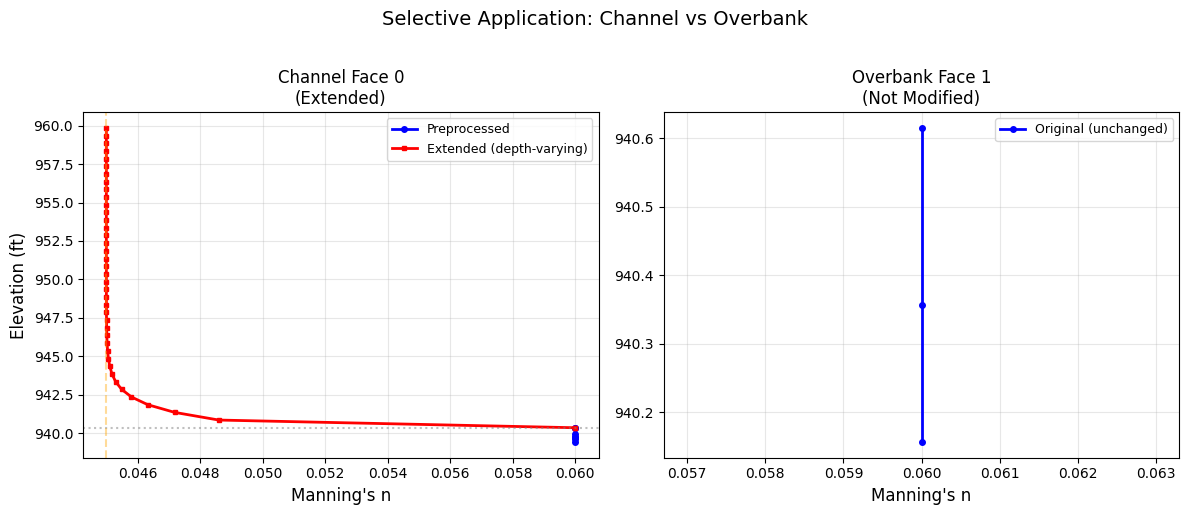

In [17]:
# --- Figure: Channel face (extended) vs Overbank face (unchanged) ---
if channel_face_ids and overbank_face_example:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

    # Channel face: extended with depth-varying n
    ax = axes[0]
    ch_orig_max = ch_before['Elevation'].max()
    ch_orig = ch_after[ch_after['Elevation'] <= ch_orig_max + 0.01]
    ch_ext = ch_after[ch_after['Elevation'] > ch_orig_max - 0.01]

    ax.plot(ch_orig[n_col], ch_orig['Elevation'], 'b-o', markersize=4,
            label='Preprocessed', linewidth=2)
    ax.plot(ch_ext[n_col], ch_ext['Elevation'], 'r-s', markersize=3,
            label='Extended (depth-varying)', linewidth=2)
    ax.axhline(y=ch_orig_max, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(x=N_ASYMPTOTE, color='orange', linestyle='--', alpha=0.4)
    ax.set_xlabel("Manning's n", fontsize=12)
    ax.set_ylabel('Elevation (ft)', fontsize=12)
    ax.set_title(f'Channel Face {channel_face_example}\n(Extended)', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Overbank face: unchanged
    ax = axes[1]
    ob_data = ob_after
    ax.plot(ob_data[n_col], ob_data['Elevation'], 'b-o', markersize=4,
            label='Original (unchanged)', linewidth=2)
    ax.set_xlabel("Manning's n", fontsize=12)
    ax.set_title(f'Overbank Face {overbank_face_example}\n(Not Modified)', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    fig.suptitle('Selective Application: Channel vs Overbank', fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("Skipping figure — no polygon-based face selection available")

## Summary

This notebook demonstrated a complete workflow for depth-varying Manning's n
in HEC-RAS 2D models:

### What We Showed

1. **Literature basis**: Manning's n decreases with flow depth — established by
   HEC-15, Limerinos (1970), Jarrett (1984), and Chow (1959)
2. **Edit-run-read loop**: Modified uniform n in the plain-text geometry file,
   ran with `force_geompre=True`, verified face property tables updated
3. **Depth-varying n**: Applied an exponential decay formula to the face property
   tables using `HdfMesh.set_face_mannings_n_values()`
4. **Table extension**: Extended face tables above terrain elevation using
   `HdfMesh.extend_face_property_tables()` with depth-varying Manning's n
5. **Selective application**: Used `polygon` parameter to modify only channel
   faces — overbank faces retained original roughness
6. **Channel delineation**: Demonstrated fluvial/pluvial classification and
   bank line extraction as channel polygon sources

### Key Architecture Points

| Workflow | Method |
|----------|--------|
| Persist n through compute | Modify `.g##` via `GeomStorage` + `force_geompre=True` |
| Direct HDF modification | `HdfMesh.set_face_mannings_n_values()` (analysis only) |
| Extend tables higher | `HdfMesh.extend_face_property_tables()` |
| Protect from RASMapper | `HdfMesh.pin_property_tables()` (but NOT from preprocessor) |
| Spatial filtering | `polygon=`, `region_name=`, or `face_ids=` parameters |
| Channel identification | Calibration regions, fluvial/pluvial, bank lines |

### Adapting for Your Project

```python
# 1. Extract your project (or point to your local copy)
ras = init_ras_project("/path/to/your/project", "7.0")

# 2. Run with force_geompre to generate face tables
RasCmdr.compute_plan("01", ras_object=ras, force_geompre=True)
ras = init_ras_project("/path/to/your/project", "7.0", ras_object="new")

# 3. Define your depth-varying n function
def my_n_func(depth, base_n):
    if depth <= 0: return base_n
    return 0.035 + (base_n - 0.035) * np.exp(-depth / 1.5)

# 4. Extend channel faces only (using calibration region)
geom_hdf = Path(ras.geom_df.iloc[0]['file_path']).with_suffix('.hdf')
HdfMesh.extend_face_property_tables(
    hdf_path=geom_hdf,
    mesh_name="Your 2D Area",
    extension_elevation=960.0,  # target elevation
    mannings_n_func=my_n_func,
    region_name="Channel",      # drawn in RASMapper
    pin_tables=True,
)
```

### References

- Chow, V.T., 1959. *Open-Channel Hydraulics*. McGraw-Hill.
- FHWA, 2005. *Design of Roadside Channels with Flexible Linings* (HEC-15). FHWA-NHI-05-114.
- Limerinos, J.T., 1970. USGS Water-Supply Paper 1898-B.
- Jarrett, R.D., 1984. *J. Hydraulic Engineering*, ASCE, 110(11): 1519-1539.
- [HEC-RAS Technical Reference — Energy Loss Coefficients](https://www.hec.usace.army.mil/confluence/rasdocs/ras1dtechref/6.6/basic-data-requirements/geometric-data/energy-loss-coefficients)
- [HEC-RAS 2D — Face Property Tables](https://www.hec.usace.army.mil/confluence/rasdocs/r2dum/latest/development-of-a-2d-or-combined-1d-2d-model/creating-hydraulic-property-tables-for-2d-flow-areas)